# Seed 11 Computer Vision Notebook (Colab)

Notebook preparado para trabalhar **apenas com a seed 11** usando os ficheiros exportados (`.npy` + `_mask.npy`) como fonte principal dos c?lculos.

## Setup

Este notebook:
- carrega prot?tipos globais e locais (`class_02`) da seed11
- valida `arr.shape == mask.shape`
- visualiza com escala fixa (`vmin=-2.025433`, `vmax=2.025433`, `coolwarm`)
- faz splits (metades e quadrantes) sobre os **arrays**
- extrai features b?sicas
- exporta CSVs para uso posterior

In [1]:
import os
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import ndimage as ndi

try:
    import cv2  # optional
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

try:
    from skimage.filters import threshold_otsu, threshold_multiotsu
    HAS_SKIMAGE = True
except Exception:
    threshold_otsu = None
    threshold_multiotsu = None
    HAS_SKIMAGE = False

print(f"OpenCV available: {HAS_CV2}")
print(f"scikit-image available: {HAS_SKIMAGE}")


OpenCV available: True
scikit-image available: True


## Mount Google Drive

In [2]:
print('Local execution: skipping Google Drive mount cell.')

Local execution: skipping Google Drive mount cell.


## Paths

In [3]:
# ============================================================
# Edita apenas esta sec??o se necess?rio
# ============================================================
BASE_DRIVE_PATH = Path(r'C:\\Users\\pedro\\Documents')
PROJECT_FOLDER_NAME = 'Filipa_dados'
PROJECT_ROOT_OVERRIDE = Path(r'C:\\Users\\pedro\\Documents\\Filipa_dados')  # Ex.: Path('/content/drive/MyDrive/Filipa_dados')

SEED_ID = 11
EXPECTED_VMIN = -2.025433
EXPECTED_VMAX = 2.025433
EXPECTED_CMAP = 'coolwarm'
EXPECTED_MASK_TRUE_IS_VALID = True  # conven??o esperada dos exports
# ============================================================


def resolve_project_root(base_drive_path: Path, project_folder_name: str, override: Path | None = None) -> Path:
    if override is not None:
        p = Path(override)
        if not p.exists():
            raise FileNotFoundError(f'PROJECT_ROOT_OVERRIDE n?o existe: {p}')
        return p

    direct = base_drive_path / project_folder_name
    if direct.exists():
        return direct

    common_alt = base_drive_path / 'Colab Notebooks' / project_folder_name
    if common_alt.exists():
        return common_alt

    # fallback: procura no Drive (pode ser mais lento)
    matches = [p for p in base_drive_path.rglob(project_folder_name) if p.is_dir()]
    if not matches:
        raise FileNotFoundError(
            f'N?o encontrei a pasta do projeto "{project_folder_name}" em {base_drive_path}. '
            'Define PROJECT_ROOT_OVERRIDE manualmente.'
        )

    matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)
    return matches[0]


def discover_seed11_export_root(project_root: Path, seed_id: int) -> Path:
    search_roots = []
    results_dir = project_root / 'results'
    if results_dir.exists():
        search_roots.append(results_dir)
    search_roots.append(project_root)

    candidates = []

    # Prefer?ncia: computer_vision_exports_seed11
    for sr in search_roots:
        for p in sr.rglob(f'computer_vision_exports_seed{seed_id}'):
            if p.is_dir() and (p / f'seed{seed_id}' / 'global').exists():
                candidates.append(p)

    # Fallback: qualquer computer_vision_exports* com seed11
    if not candidates:
        for sr in search_roots:
            for p in sr.rglob('computer_vision_exports*'):
                if p.is_dir() and (p / f'seed{seed_id}' / 'global').exists():
                    candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            f'N?o encontrei exports para seed{seed_id}. Procurei abaixo de: {search_roots}'
        )

    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]


PROJECT_ROOT = resolve_project_root(
    base_drive_path=BASE_DRIVE_PATH,
    project_folder_name=PROJECT_FOLDER_NAME,
    override=PROJECT_ROOT_OVERRIDE,
)

CV_EXPORT_ROOT = discover_seed11_export_root(PROJECT_ROOT, seed_id=SEED_ID)
SEED_ROOT = CV_EXPORT_ROOT / f'seed{SEED_ID}'
GLOBAL_DIR = SEED_ROOT / 'global'
LOCAL_CLASS02_DIR = SEED_ROOT / 'local_class02'
MANIFEST_PATH = CV_EXPORT_ROOT / 'manifest_cv_exports.json'

NOTEBOOK_OUTPUT_DIR = CV_EXPORT_ROOT / f'cv_notebook_outputs_seed{SEED_ID}'
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT      :', PROJECT_ROOT)
print('CV_EXPORT_ROOT    :', CV_EXPORT_ROOT)
print('SEED_ROOT         :', SEED_ROOT)
print('GLOBAL_DIR        :', GLOBAL_DIR)
print('LOCAL_CLASS02_DIR :', LOCAL_CLASS02_DIR)
print('MANIFEST_PATH     :', MANIFEST_PATH)
print('NOTEBOOK_OUTPUT_DIR:', NOTEBOOK_OUTPUT_DIR)


PROJECT_ROOT      : C:\Users\pedro\Documents\Filipa_dados
CV_EXPORT_ROOT    : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11
SEED_ROOT         : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\seed11
GLOBAL_DIR        : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\seed11\global
LOCAL_CLASS02_DIR : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\seed11\local_class02
MANIFEST_PATH     : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\manifest_cv_exports.json
NOTEBOOK_OUTPUT_DIR: C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\cv_notebook_outp

## Discover files

In [4]:
def discover_global_prototypes(global_dir: Path):
    records = []
    for arr_path in sorted(global_dir.glob('prototype_class_*.npy')):
        if arr_path.name.endswith('_mask.npy'):
            continue
        base = arr_path.stem
        mask_path = arr_path.with_name(base + '_mask.npy')
        clean_png_path = arr_path.with_name(base + '_clean.png')
        records.append(
            {
                'name': base,
                'arr_path': arr_path,
                'mask_path': mask_path,
                'clean_png_path': clean_png_path,
                'scope': 'global',
            }
        )
    return records


def discover_local_class02_prototypes(local_class02_dir: Path):
    records = []
    for k_dir in sorted(local_class02_dir.glob('k*')):
        if not k_dir.is_dir():
            continue
        for arr_path in sorted(k_dir.glob('subclass_prototype_*.npy')):
            if arr_path.name.endswith('_mask.npy'):
                continue
            base = arr_path.stem
            mask_path = arr_path.with_name(base + '_mask.npy')
            clean_png_path = arr_path.with_name(base + '_clean.png')
            records.append(
                {
                    'name': base,
                    'arr_path': arr_path,
                    'mask_path': mask_path,
                    'clean_png_path': clean_png_path,
                    'scope': 'local_class02',
                    'k': k_dir.name,
                }
            )
    return records


global_records = discover_global_prototypes(GLOBAL_DIR)
local_records = discover_local_class02_prototypes(LOCAL_CLASS02_DIR)

print(f'Prot?tipos globais encontrados: {len(global_records)}')
for r in global_records:
    print('  -', r['name'])

print(f'Prot?tipos locais class_02 encontrados: {len(local_records)}')
for r in local_records:
    print(f"  - {r['k']}/{r['name']}")

if len(global_records) == 0:
    raise RuntimeError('Nenhum prot?tipo global encontrado.')
if len(local_records) == 0:
    raise RuntimeError('Nenhum prot?tipo local class_02 encontrado.')


Prot?tipos globais encontrados: 5
  - prototype_class_01
  - prototype_class_02
  - prototype_class_03
  - prototype_class_04
  - prototype_class_05
Prot?tipos locais class_02 encontrados: 2
  - k2/subclass_prototype_01
  - k2/subclass_prototype_02


## Load and validate data

In [5]:
def load_prototype(arr_path, mask_path):
    arr = np.load(arr_path).astype(np.float32, copy=False)
    mask = np.load(mask_path).astype(bool, copy=False)
    if arr.shape != mask.shape:
        raise ValueError(f'Shape mismatch: arr={arr.shape}, mask={mask.shape} em {arr_path}')
    return arr, mask


def masked_mean(arr, mask):
    valid = mask & np.isfinite(arr)
    if not np.any(valid):
        return float('nan')
    return float(np.nanmean(arr[valid]))


def masked_std(arr, mask):
    valid = mask & np.isfinite(arr)
    if not np.any(valid):
        return float('nan')
    return float(np.nanstd(arr[valid]))


def split_halves(arr, mask):
    h, w = arr.shape
    h_mid = h // 2
    w_mid = w // 2

    # Conven??o espacial para plotting com origin='lower':
    # top = linhas com ?ndices maiores; bottom = ?ndices menores.
    return {
        'left': (arr[:, :w_mid], mask[:, :w_mid]),
        'right': (arr[:, w_mid:], mask[:, w_mid:]),
        'top': (arr[h_mid:, :], mask[h_mid:, :]),
        'bottom': (arr[:h_mid, :], mask[:h_mid, :]),
    }


def split_quadrants(arr, mask):
    h, w = arr.shape
    h_mid = h // 2
    w_mid = w // 2

    # Q1 Q2
    # Q3 Q4
    # (origem em baixo para visualiza??o)
    return {
        'Q1': (arr[h_mid:, :w_mid], mask[h_mid:, :w_mid]),   # top-left
        'Q2': (arr[h_mid:, w_mid:], mask[h_mid:, w_mid:]),   # top-right
        'Q3': (arr[:h_mid, :w_mid], mask[:h_mid, :w_mid]),   # bottom-left
        'Q4': (arr[:h_mid, w_mid:], mask[:h_mid, w_mid:]),   # bottom-right
    }


def masked_plot(arr, mask, title=None, ax=None, vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP, show_colorbar=False):
    arr_plot = arr.astype(np.float32, copy=True)
    arr_plot[~mask] = np.nan

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    im = ax.imshow(arr_plot, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    if title is not None:
        ax.set_title(title)
    ax.axis('off')

    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


def infer_mask_true_is_valid(samples_dict):
    scores = []
    for item in samples_dict.values():
        arr = item['arr']
        mask = item['mask']
        true_finite = float(np.mean(np.isfinite(arr[mask]))) if np.any(mask) else np.nan
        false_finite = float(np.mean(np.isfinite(arr[~mask]))) if np.any(~mask) else np.nan
        if np.isfinite(true_finite) and np.isfinite(false_finite):
            scores.append(true_finite - false_finite)

    if len(scores) == 0:
        return EXPECTED_MASK_TRUE_IS_VALID, np.nan

    mean_score = float(np.mean(scores))
    inferred_true_valid = mean_score >= 0.0
    return inferred_true_valid, mean_score


# Carregar dados globais
global_data = {}
for rec in global_records:
    arr, mask = load_prototype(rec['arr_path'], rec['mask_path'])
    global_data[rec['name']] = {
        'arr': arr,
        'mask': mask,
        'meta': rec,
    }

# Carregar dados locais class_02
local_data = {}
for rec in local_records:
    arr, mask = load_prototype(rec['arr_path'], rec['mask_path'])
    key = f"{rec['k']}::{rec['name']}"
    local_data[key] = {
        'arr': arr,
        'mask': mask,
        'meta': rec,
    }

# Inferir conven??o de m?scara (evid?ncia num?rica)
all_data = {}
all_data.update({f'global::{k}': v for k, v in global_data.items()})
all_data.update({f'local::{k}': v for k, v in local_data.items()})

inferred_true_valid, convention_score = infer_mask_true_is_valid(all_data)
ANALYSIS_MASK_TRUE_IS_VALID = inferred_true_valid

print('Conven??o esperada: True = oceano/v?lido, False = terra/inv?lido')
print('Conven??o inferida (evid?ncia):', 'True=valid' if inferred_true_valid else 'True=invalid')
print('Score evid?ncia (maior ? mais compat?vel com True=valid):', convention_score)

if ANALYSIS_MASK_TRUE_IS_VALID != EXPECTED_MASK_TRUE_IS_VALID:
    print('Aten??o: evid?ncia sugere conven??o oposta. A inverter m?scaras para an?lise.')
    for d in [global_data, local_data]:
        for k in d:
            d[k]['mask'] = ~d[k]['mask']

# Validar shapes e correspond?ncia array/m?scara
validation_rows = []
for scope_name, dataset in [('global', global_data), ('local_class02', local_data)]:
    for key, item in dataset.items():
        arr = item['arr']
        mask = item['mask']
        validation_rows.append(
            {
                'scope': scope_name,
                'name': key,
                'arr_shape': tuple(arr.shape),
                'mask_shape': tuple(mask.shape),
                'shape_match': tuple(arr.shape) == tuple(mask.shape),
                'mask_true_fraction': float(np.mean(mask)),
            }
        )

validation_df = pd.DataFrame(validation_rows)

a = validation_df['shape_match'].all()
if not a:
    raise RuntimeError('H? prot?tipos com arr/mask sem shape igual.')

print('--- Valida??o ---')
print(f'Seed usada: {SEED_ID}')
print(f'Prot?tipos globais: {len(global_data)}')
print(f'Prot?tipos locais class_02: {len(local_data)}')
print('Shapes globais:', sorted({tuple(v['arr'].shape) for v in global_data.values()}))
print('Shapes locais :', sorted({tuple(v['arr'].shape) for v in local_data.values()}))
print('Correspond?ncia arr/mask:', 'OK' if a else 'FALHA')

if SEED_ID != 11:
    raise RuntimeError(f'Este notebook est? configurado para seed11, mas SEED_ID={SEED_ID}')

validation_df


Conven??o esperada: True = oceano/v?lido, False = terra/inv?lido
Conven??o inferida (evid?ncia): True=valid
Score evid?ncia (maior ? mais compat?vel com True=valid): 1.0
--- Valida??o ---
Seed usada: 11
Prot?tipos globais: 5
Prot?tipos locais class_02: 2
Shapes globais: [(64, 112)]
Shapes locais : [(64, 112)]
Correspond?ncia arr/mask: OK


,scope,name,arr_shape,mask_shape,shape_match,mask_true_fraction
0,global,prototype_class_01,"(64, 112)","(64, 112)",True,0.966099
1,global,prototype_class_02,"(64, 112)","(64, 112)",True,0.966099
2,global,prototype_class_03,"(64, 112)","(64, 112)",True,0.966099
3,global,prototype_class_04,"(64, 112)","(64, 112)",True,0.966099
4,global,prototype_class_05,"(64, 112)","(64, 112)",True,0.966099
5,local_class02,k2::subclass_prototype_01,"(64, 112)","(64, 112)",True,0.966099
6,local_class02,k2::subclass_prototype_02,"(64, 112)","(64, 112)",True,0.966099


## Visualize global prototypes

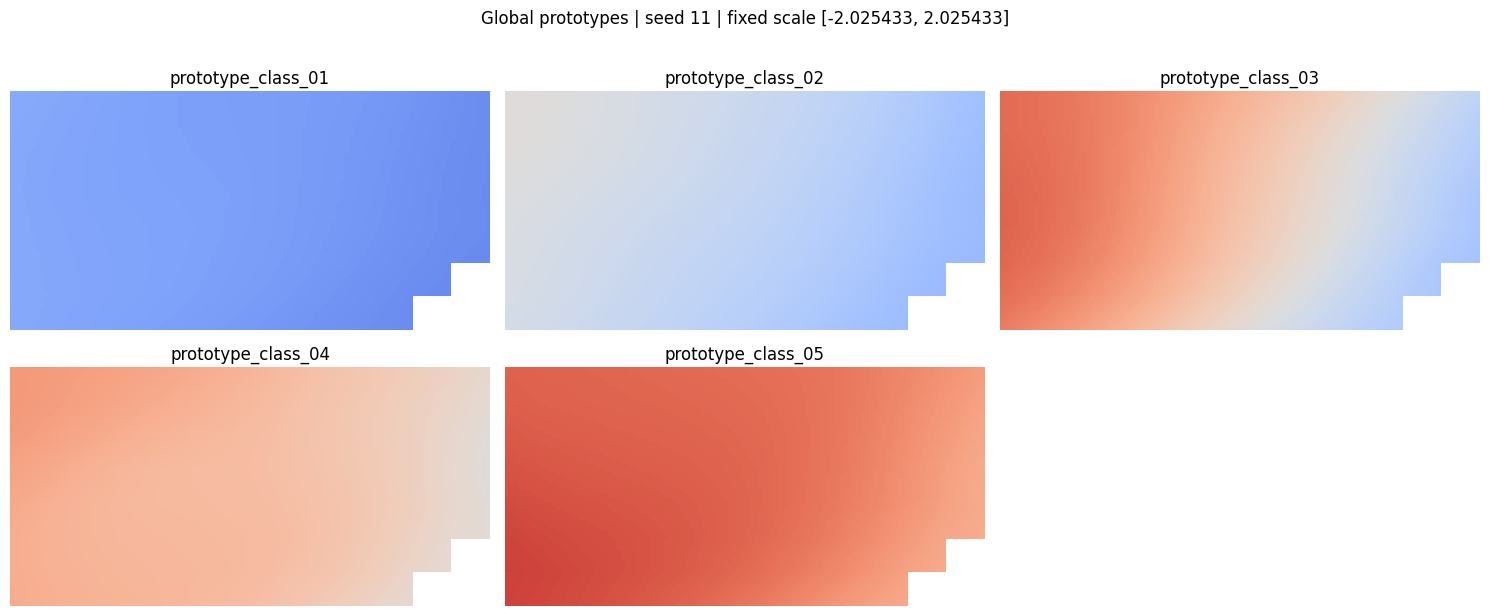

In [6]:
global_names = sorted(global_data.keys())
n_global = len(global_names)
cols = min(3, n_global)
rows = math.ceil(n_global / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.0 * rows), squeeze=False)

for i, name in enumerate(global_names):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    arr = global_data[name]['arr']
    mask = global_data[name]['mask']
    masked_plot(arr, mask, title=name, ax=ax, vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)

for j in range(n_global, rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis('off')

fig.suptitle(f'Global prototypes | seed {SEED_ID} | fixed scale [{EXPECTED_VMIN}, {EXPECTED_VMAX}]', y=1.02)
fig.tight_layout()
plt.show()


## Visualize local class_02 prototypes

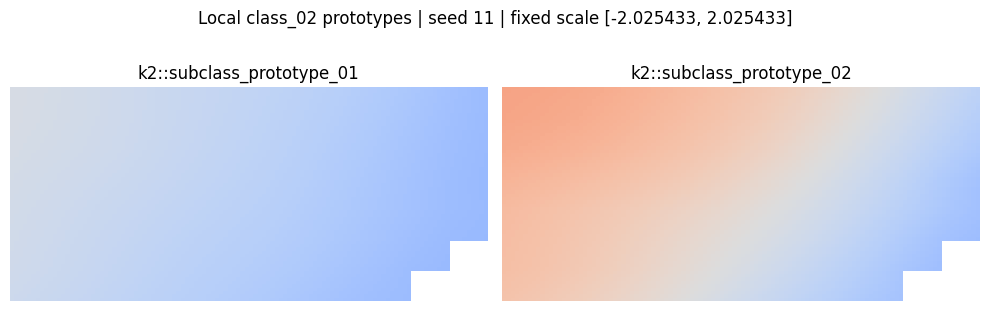

In [7]:
local_names = sorted(local_data.keys())
n_local = len(local_names)
cols = min(2, max(1, n_local))
rows = math.ceil(n_local / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.0 * rows), squeeze=False)

for i, key in enumerate(local_names):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    item = local_data[key]
    title = key
    masked_plot(item['arr'], item['mask'], title=title, ax=ax, vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)

for j in range(n_local, rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis('off')

fig.suptitle(f'Local class_02 prototypes | seed {SEED_ID} | fixed scale [{EXPECTED_VMIN}, {EXPECTED_VMAX}]', y=1.02)
fig.tight_layout()
plt.show()


## Split arrays

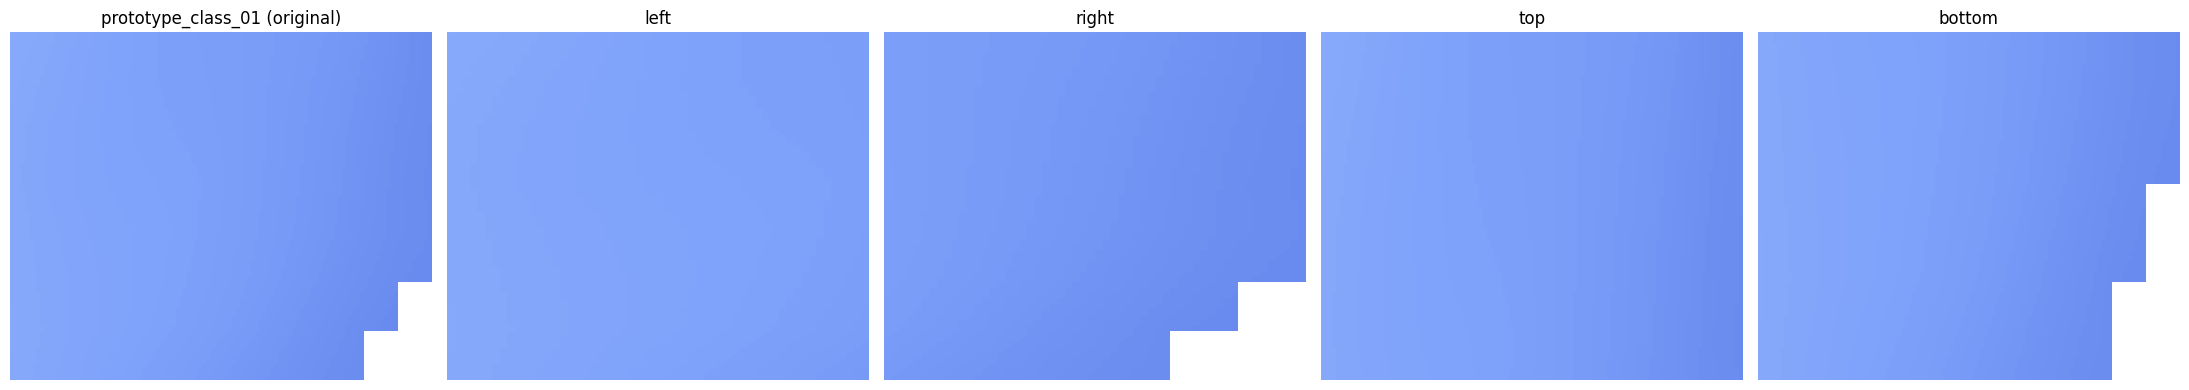

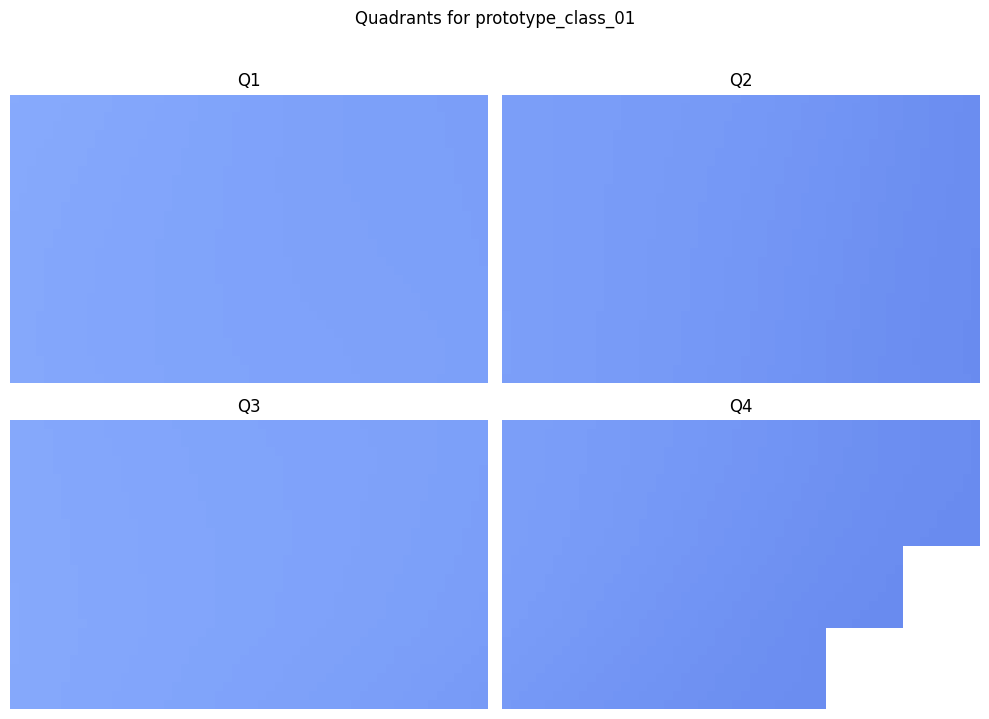

In [8]:
# Exemplo com o primeiro prot?tipo global dispon?vel
example_name = sorted(global_data.keys())[0]
example_arr = global_data[example_name]['arr']
example_mask = global_data[example_name]['mask']

halves = split_halves(example_arr, example_mask)
quadrants = split_quadrants(example_arr, example_mask)

# Original + metades
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
masked_plot(example_arr, example_mask, title=f'{example_name} (original)', ax=axes[0], vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)
masked_plot(*halves['left'], title='left', ax=axes[1], vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)
masked_plot(*halves['right'], title='right', ax=axes[2], vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)
masked_plot(*halves['top'], title='top', ax=axes[3], vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)
masked_plot(*halves['bottom'], title='bottom', ax=axes[4], vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)
fig.tight_layout()
plt.show()

# Quadrantes
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
q_names = ['Q1', 'Q2', 'Q3', 'Q4']
for ax, qn in zip(axes.flat, q_names):
    masked_plot(*quadrants[qn], title=qn, ax=ax, vmin=EXPECTED_VMIN, vmax=EXPECTED_VMAX, cmap=EXPECTED_CMAP)
fig.suptitle(f'Quadrants for {example_name}', y=1.02)
fig.tight_layout()
plt.show()


## Extract basic features

In [9]:
def extract_basic_features(prototype_name, arr, mask):
    halves = split_halves(arr, mask)

    mean_all = masked_mean(arr, mask)
    std_all = masked_std(arr, mask)

    mean_left = masked_mean(*halves['left'])
    mean_right = masked_mean(*halves['right'])
    mean_top = masked_mean(*halves['top'])
    mean_bottom = masked_mean(*halves['bottom'])

    return {
        'prototype_name': prototype_name,
        'mean': mean_all,
        'std': std_all,
        'mean_left': mean_left,
        'mean_right': mean_right,
        'mean_top': mean_top,
        'mean_bottom': mean_bottom,
        'contrast_lr': mean_left - mean_right,
        'contrast_tb': mean_top - mean_bottom,
    }


# Features globais
global_rows = []
for name in sorted(global_data.keys()):
    item = global_data[name]
    row = extract_basic_features(name, item['arr'], item['mask'])
    row['seed'] = SEED_ID
    row['scope'] = 'global'
    global_rows.append(row)

features_global_df = pd.DataFrame(global_rows).sort_values('prototype_name').reset_index(drop=True)

# Features locais class_02
local_rows = []
for key in sorted(local_data.keys()):
    item = local_data[key]
    row = extract_basic_features(item['meta']['name'], item['arr'], item['mask'])
    row['seed'] = SEED_ID
    row['scope'] = 'local_class02'
    row['k'] = item['meta'].get('k', '')
    row['key'] = key
    local_rows.append(row)

features_local_df = pd.DataFrame(local_rows).sort_values(['k', 'prototype_name']).reset_index(drop=True)

print('DataFrame global:')
display(features_global_df)

print('DataFrame local class_02:')
display(features_local_df)

# Hooks para futuras features (gradiente/orienta??o/fronts)
print('Notebook pronto para extens?o futura: gradientes, orienta??o dominante, front strength, front area ratio.')


DataFrame global:


,prototype_name,mean,std,mean_left,mean_right,mean_top,mean_bottom,contrast_lr,contrast_tb,seed,scope
0,prototype_class_01,-1.227090,0.090882,-1.154202,-1.305280,-1.225263,-1.229051,0.151078,0.003788,11,global
1,prototype_class_02,-0.387270,0.242185,-0.195395,-0.593100,-0.340100,-0.437870,0.397704,0.097770,11,global
2,prototype_class_03,0.510277,0.647744,1.046715,-0.065177,0.576718,0.439004,1.111892,0.137714,11,global
3,prototype_class_04,0.579936,0.219440,0.746714,0.401028,0.597116,0.561505,0.345686,0.035611,11,global
4,prototype_class_05,1.377047,0.227372,1.549461,1.192092,1.360058,1.395271,0.357369,-0.035213,11,global


DataFrame local class_02:


,prototype_name,mean,std,mean_left,mean_right,mean_top,mean_bottom,contrast_lr,contrast_tb,seed,scope,k,key
0,subclass_prototype_01,-0.472178,0.209379,-0.305001,-0.651515,-0.438787,-0.507998,0.346514,0.069211,11,local_class02,k2,k2::subclass_prototype_01
1,subclass_prototype_02,0.137162,0.450664,0.481577,-0.232303,0.269434,-0.004730,0.713880,0.274164,11,local_class02,k2,k2::subclass_prototype_02


Notebook pronto para extens?o futura: gradientes, orienta??o dominante, front strength, front area ratio.


## Simple regime analysis

Main regime analysis over `.npy` arrays (`arr` + `mask`) with a simple, interpretable and conservative pipeline.


In [10]:
# ------------------------------------------------------------
# Adjustable thresholds for conservative decision logic
# ------------------------------------------------------------
SIMPLE_SIGMA = 1.0

SIMPLE_RULES = {
    'homogeneous_std_max': 0.18,
    'homogeneous_p90_grad_max': 0.12,
    'homogeneous_front_area_max': 0.12,
    'multi_min_region_ratio_min': 0.18,
    'multi_inter_region_diff_min': 0.45,
    'multi_coherence_min': 0.65,
    'multi_front_area_ratio_min': 0.15,
    'multi_p90_grad_min': 0.16,
}


def get_valid_values(arr, mask):
    valid = mask & np.isfinite(arr)
    return arr[valid].astype(np.float32, copy=False)


def simple_prepare(arr, mask, sigma=1.0):
    arr_f = np.asarray(arr, dtype=np.float32)
    mask_b = np.asarray(mask, dtype=bool)
    valid = mask_b & np.isfinite(arr_f)

    smoothed = np.full(arr_f.shape, np.nan, dtype=np.float32)
    if not np.any(valid):
        return smoothed

    w = valid.astype(np.float32)
    arr0 = np.where(valid, arr_f, 0.0).astype(np.float32, copy=False)

    if sigma is None or sigma <= 0:
        smoothed[valid] = arr0[valid]
    else:
        num = ndi.gaussian_filter(arr0 * w, sigma=float(sigma), mode='nearest')
        den = ndi.gaussian_filter(w, sigma=float(sigma), mode='nearest')
        ok = den > 1e-6
        smoothed[ok] = (num[ok] / den[ok]).astype(np.float32, copy=False)

    smoothed[~mask_b] = np.nan
    return smoothed


def simple_global_metrics(arr_smooth, mask):
    vals = get_valid_values(arr_smooth, mask)
    if vals.size == 0:
        return {
            'std_temp': float('nan'),
            'iqr_temp': float('nan'),
            'range_temp': float('nan'),
        }

    p25, p75 = np.percentile(vals, [25, 75])
    return {
        'std_temp': float(np.nanstd(vals)),
        'iqr_temp': float(p75 - p25),
        'range_temp': float(np.nanmax(vals) - np.nanmin(vals)),
    }


def otsu_segmentation(arr_smooth, mask):
    vals = get_valid_values(arr_smooth, mask)
    labels = np.full(arr_smooth.shape, -1, dtype=np.int8)
    region_low = np.zeros(arr_smooth.shape, dtype=bool)
    region_high = np.zeros(arr_smooth.shape, dtype=bool)

    if vals.size == 0:
        return {
            'threshold': float('nan'),
            'threshold_method': 'empty',
            'labels': labels,
            'region_low': region_low,
            'region_high': region_high,
        }

    threshold_method = 'mean_fallback'
    threshold = float(np.nanmean(vals))

    if HAS_SKIMAGE and threshold_otsu is not None and np.unique(vals).size > 1:
        try:
            threshold = float(threshold_otsu(vals))
            threshold_method = 'otsu'
        except Exception:
            threshold_method = 'mean_fallback'

    valid = mask & np.isfinite(arr_smooth)
    region_low = valid & (arr_smooth < threshold)
    region_high = valid & (~region_low)

    labels[region_low] = 0
    labels[region_high] = 1

    return {
        'threshold': threshold,
        'threshold_method': threshold_method,
        'labels': labels,
        'region_low': region_low,
        'region_high': region_high,
    }


def optional_multiotsu_thresholds(arr_smooth, mask, classes=3):
    vals = get_valid_values(arr_smooth, mask)
    if not HAS_SKIMAGE or threshold_multiotsu is None:
        return None
    if vals.size < classes:
        return None
    if np.unique(vals).size < classes:
        return None
    try:
        t = threshold_multiotsu(vals, classes=classes)
    except Exception:
        return None
    return [float(x) for x in t]


def largest_component_ratio(binary_region):
    region = np.asarray(binary_region, dtype=bool)
    total = int(region.sum())
    if total == 0:
        return 0.0

    comp_map, n_comp = ndi.label(region)
    if n_comp == 0:
        return 0.0

    comp_sizes = np.bincount(comp_map.ravel())[1:]
    if comp_sizes.size == 0:
        return 0.0

    largest = int(comp_sizes.max())
    return float(largest / total)


def region_metrics(arr_smooth, mask, region_low, region_high):
    valid = mask & np.isfinite(arr_smooth)
    n_valid = int(valid.sum())
    if n_valid == 0:
        return {
            'low_ratio': float('nan'),
            'high_ratio': float('nan'),
            'min_region_ratio': float('nan'),
            'inter_region_diff': float('nan'),
            'coherence_low': float('nan'),
            'coherence_high': float('nan'),
            'coherence_min': float('nan'),
        }

    n_low = int(region_low.sum())
    n_high = int(region_high.sum())

    low_ratio = float(n_low / n_valid)
    high_ratio = float(n_high / n_valid)
    min_region_ratio = float(min(low_ratio, high_ratio))

    mean_low = float(np.nanmean(arr_smooth[region_low])) if n_low > 0 else float('nan')
    mean_high = float(np.nanmean(arr_smooth[region_high])) if n_high > 0 else float('nan')
    if np.isfinite(mean_low) and np.isfinite(mean_high):
        inter_region_diff = float(abs(mean_high - mean_low))
    else:
        inter_region_diff = 0.0

    coherence_low = float(largest_component_ratio(region_low))
    coherence_high = float(largest_component_ratio(region_high))
    coherence_min = float(min(coherence_low, coherence_high))

    return {
        'low_ratio': low_ratio,
        'high_ratio': high_ratio,
        'min_region_ratio': min_region_ratio,
        'inter_region_diff': inter_region_diff,
        'coherence_low': coherence_low,
        'coherence_high': coherence_high,
        'coherence_min': coherence_min,
    }


def simple_front_metrics(arr_smooth, mask):
    valid = mask & np.isfinite(arr_smooth)
    grad_mag = np.full(arr_smooth.shape, np.nan, dtype=np.float32)
    front_binary = np.zeros(arr_smooth.shape, dtype=bool)

    if not np.any(valid):
        return {
            'mean_grad': float('nan'),
            'p90_grad': float('nan'),
            'front_area_ratio': float('nan'),
            'grad_mag': grad_mag,
            'front_binary': front_binary,
        }

    fill_value = float(np.nanmean(arr_smooth[valid]))
    arr_for_grad = np.where(valid, arr_smooth, fill_value).astype(np.float32, copy=False)
    gy, gx = np.gradient(arr_for_grad)
    grad = np.hypot(gx, gy).astype(np.float32, copy=False)
    grad[~valid] = np.nan
    grad_mag = grad

    gvals = grad_mag[valid]
    mean_grad = float(np.nanmean(gvals))
    p90_grad = float(np.percentile(gvals, 90))

    front_binary = valid & (grad_mag >= p90_grad)
    front_area_ratio = float(front_binary.sum() / valid.sum())

    return {
        'mean_grad': mean_grad,
        'p90_grad': p90_grad,
        'front_area_ratio': front_area_ratio,
        'grad_mag': grad_mag,
        'front_binary': front_binary,
    }


def extract_simple_regime_metrics(prototype_name, arr, mask, sigma=1.0):
    arr_smooth = simple_prepare(arr, mask, sigma=sigma)
    gm = simple_global_metrics(arr_smooth, mask)
    seg = otsu_segmentation(arr_smooth, mask)
    rm = region_metrics(arr_smooth, mask, seg['region_low'], seg['region_high'])
    fm = simple_front_metrics(arr_smooth, mask)

    row = {
        'prototype_name': prototype_name,
        'sigma': float(sigma),
        'threshold': float(seg['threshold']) if np.isfinite(seg['threshold']) else float('nan'),
        'std_temp': gm['std_temp'],
        'iqr_temp': gm['iqr_temp'],
        'range_temp': gm['range_temp'],
        'low_ratio': rm['low_ratio'],
        'high_ratio': rm['high_ratio'],
        'min_region_ratio': rm['min_region_ratio'],
        'inter_region_diff': rm['inter_region_diff'],
        'coherence_low': rm['coherence_low'],
        'coherence_high': rm['coherence_high'],
        'coherence_min': rm['coherence_min'],
        'mean_grad': fm['mean_grad'],
        'p90_grad': fm['p90_grad'],
        'front_area_ratio': fm['front_area_ratio'],
        'threshold_method': seg['threshold_method'],
        'multiotsu_thresholds': optional_multiotsu_thresholds(arr_smooth, mask, classes=3),
    }

    aux = {
        'arr_smooth': arr_smooth,
        'labels': seg['labels'],
        'region_low': seg['region_low'],
        'region_high': seg['region_high'],
        'grad_mag': fm['grad_mag'],
        'front_binary': fm['front_binary'],
    }
    return row, aux


def decide_regime_label_simple(row, rules=SIMPLE_RULES):
    std_temp = float(row.get('std_temp', np.nan))
    p90_grad = float(row.get('p90_grad', np.nan))
    front_area_ratio = float(row.get('front_area_ratio', np.nan))

    min_region_ratio = float(row.get('min_region_ratio', np.nan))
    inter_region_diff = float(row.get('inter_region_diff', np.nan))
    coherence_min = float(row.get('coherence_min', np.nan))

    homogeneous = (
        std_temp < rules['homogeneous_std_max']
        and p90_grad < rules['homogeneous_p90_grad_max']
        and front_area_ratio < rules['homogeneous_front_area_max']
    )

    if homogeneous:
        return 'homogeneous'

    multi_regime = (
        min_region_ratio >= rules['multi_min_region_ratio_min']
        and inter_region_diff >= rules['multi_inter_region_diff_min']
        and coherence_min >= rules['multi_coherence_min']
        and front_area_ratio >= rules['multi_front_area_ratio_min']
        and p90_grad >= rules['multi_p90_grad_min']
    )

    if multi_regime:
        return 'multi_regime'

    return 'single_gradient'


In [11]:
# ----------------------
# Apply to global set
# ----------------------
simple_global_rows = []
simple_global_aux = {}

for name in sorted(global_data.keys()):
    item = global_data[name]
    row, aux = extract_simple_regime_metrics(
        prototype_name=name,
        arr=item['arr'],
        mask=item['mask'],
        sigma=SIMPLE_SIGMA,
    )
    row['seed'] = SEED_ID
    row['scope'] = 'global'
    row['regime_label'] = decide_regime_label_simple(row)
    simple_global_rows.append(row)
    simple_global_aux[name] = aux

simple_global_df = pd.DataFrame(simple_global_rows).sort_values('prototype_name').reset_index(drop=True)

print('Simple global regime labels:')
display(simple_global_df[['prototype_name', 'regime_label', 'std_temp', 'p90_grad', 'front_area_ratio', 'min_region_ratio', 'inter_region_diff', 'coherence_min']])
display(simple_global_df['regime_label'].value_counts(dropna=False))


# ----------------------
# Apply to local class_02
# ----------------------
simple_local_rows = []
simple_local_aux = {}

for key in sorted(local_data.keys()):
    item = local_data[key]
    prototype_name = item['meta']['name']
    row, aux = extract_simple_regime_metrics(
        prototype_name=prototype_name,
        arr=item['arr'],
        mask=item['mask'],
        sigma=SIMPLE_SIGMA,
    )
    row['seed'] = SEED_ID
    row['scope'] = 'local_class02'
    row['k'] = item['meta'].get('k', '')
    row['key'] = key
    row['regime_label'] = decide_regime_label_simple(row)
    simple_local_rows.append(row)
    simple_local_aux[key] = aux

simple_local_df = pd.DataFrame(simple_local_rows).sort_values(['k', 'prototype_name']).reset_index(drop=True)

print('Simple local class_02 regime labels:')
display(simple_local_df[['k', 'prototype_name', 'key', 'regime_label', 'std_temp', 'p90_grad', 'front_area_ratio', 'min_region_ratio', 'inter_region_diff', 'coherence_min']])
display(simple_local_df['regime_label'].value_counts(dropna=False))


Simple global regime labels:


,prototype_name,regime_label,std_temp,p90_grad,front_area_ratio,min_region_ratio,inter_region_diff,coherence_min
0,prototype_class_01,homogeneous,0.090818,0.005250,0.100072,0.357401,0.163965,1.0
1,prototype_class_02,single_gradient,0.242039,0.010692,0.100072,0.440722,0.419723,1.0
2,prototype_class_03,single_gradient,0.647373,0.027869,0.100072,0.459495,1.139561,1.0
3,prototype_class_04,single_gradient,0.219245,0.014162,0.100072,0.321733,0.391867,1.0
4,prototype_class_05,single_gradient,0.227158,0.016219,0.100072,0.293574,0.432492,1.0


regime_label
single_gradient    4
homogeneous        1
Name: count, dtype: int64

Simple local class_02 regime labels:


,k,prototype_name,key,regime_label,std_temp,p90_grad,front_area_ratio,min_region_ratio,inter_region_diff,coherence_min
0,k2,subclass_prototype_01,k2::subclass_prototype_01,single_gradient,0.209256,0.009159,0.100072,0.445054,0.360895,1.0
1,k2,subclass_prototype_02,k2::subclass_prototype_02,single_gradient,0.450355,0.021725,0.100072,0.425126,0.789528,1.0


regime_label
single_gradient    2
Name: count, dtype: int64

## Intuitive final CV visualization

Top row: original prototype. Bottom row: final CV interpretation (`homogeneous`, `single_gradient`, `multi_regime`).


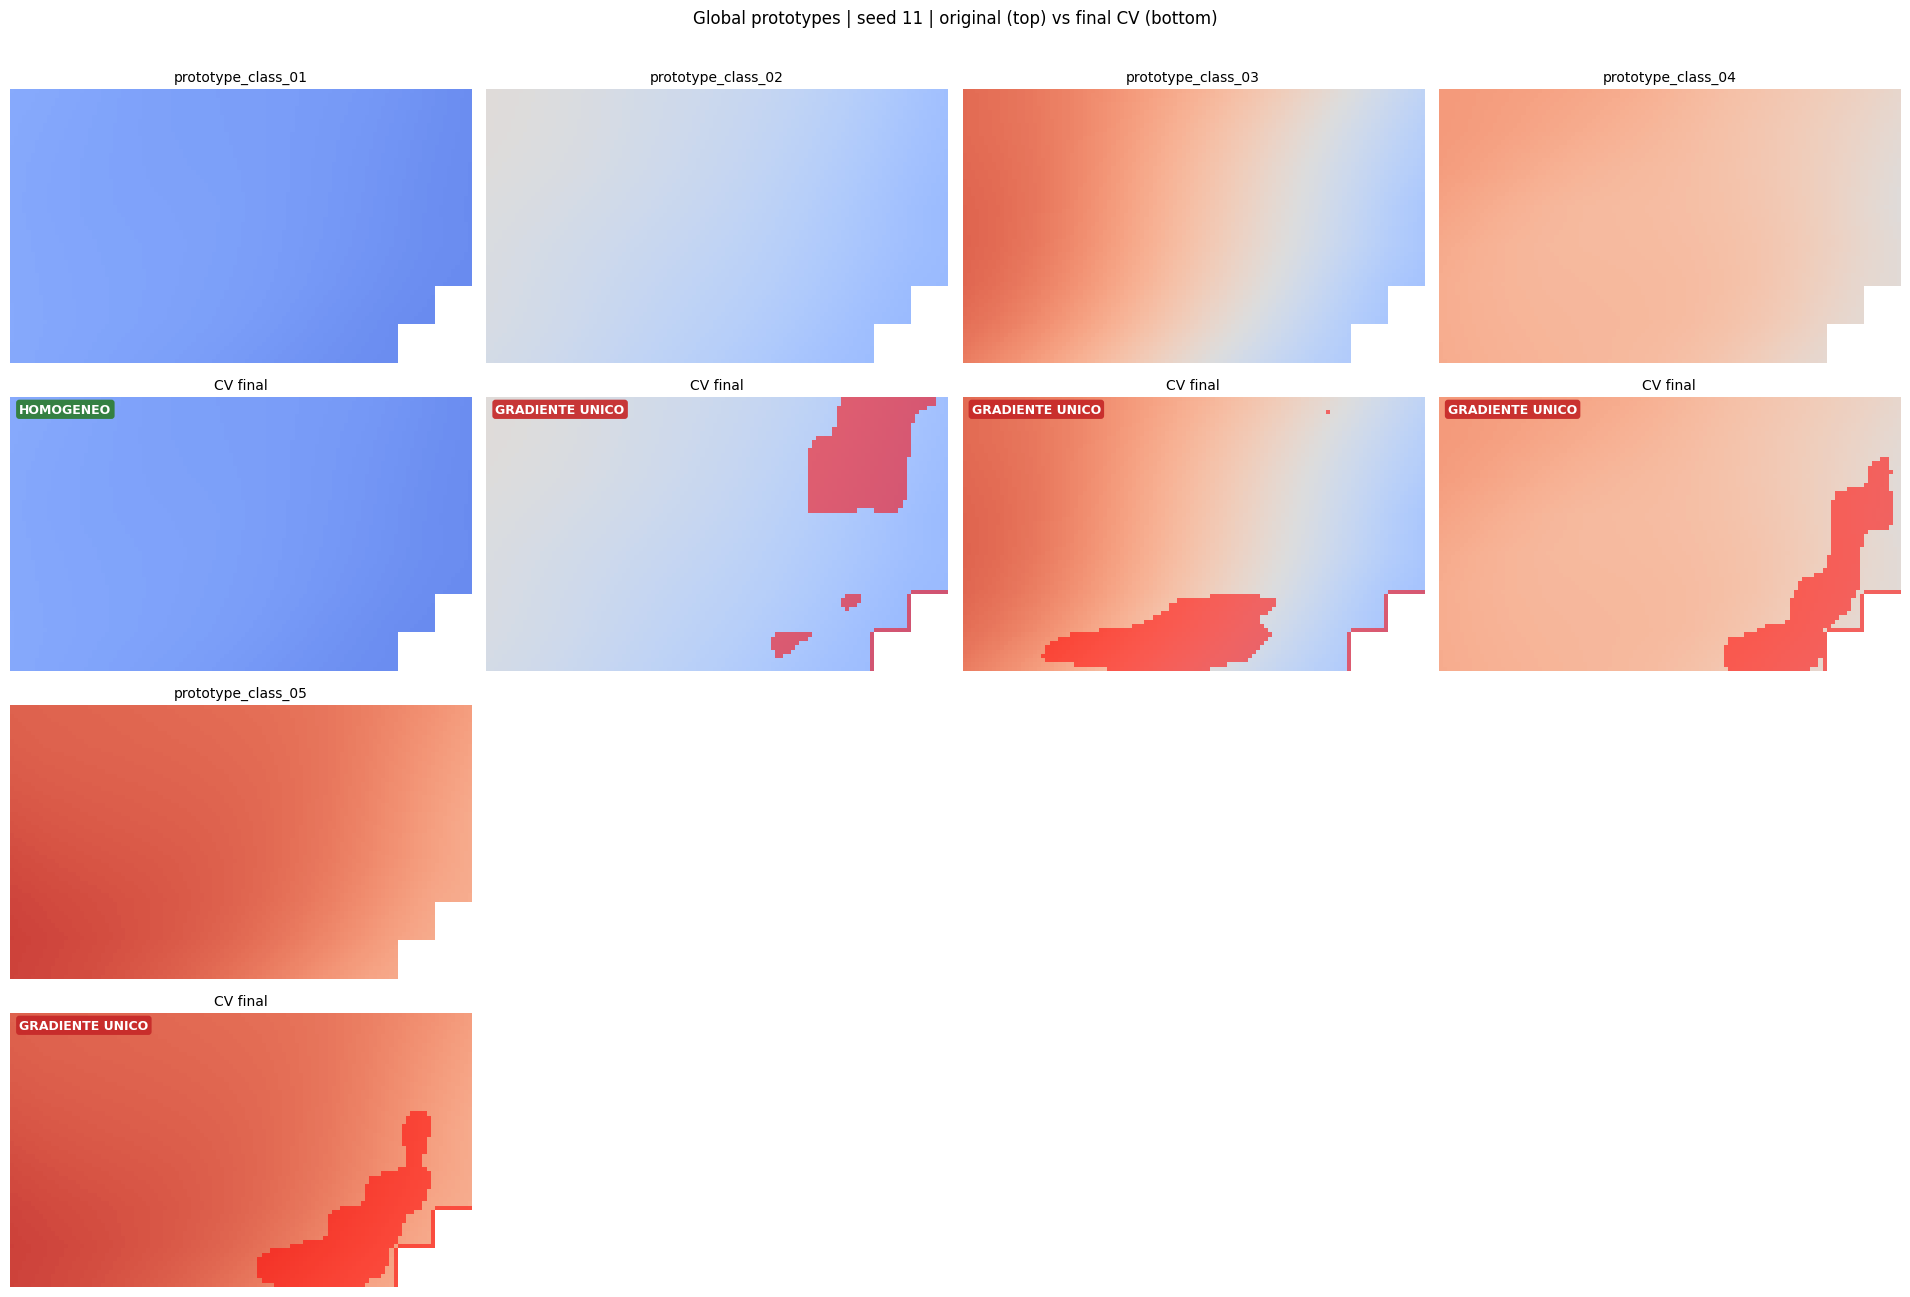

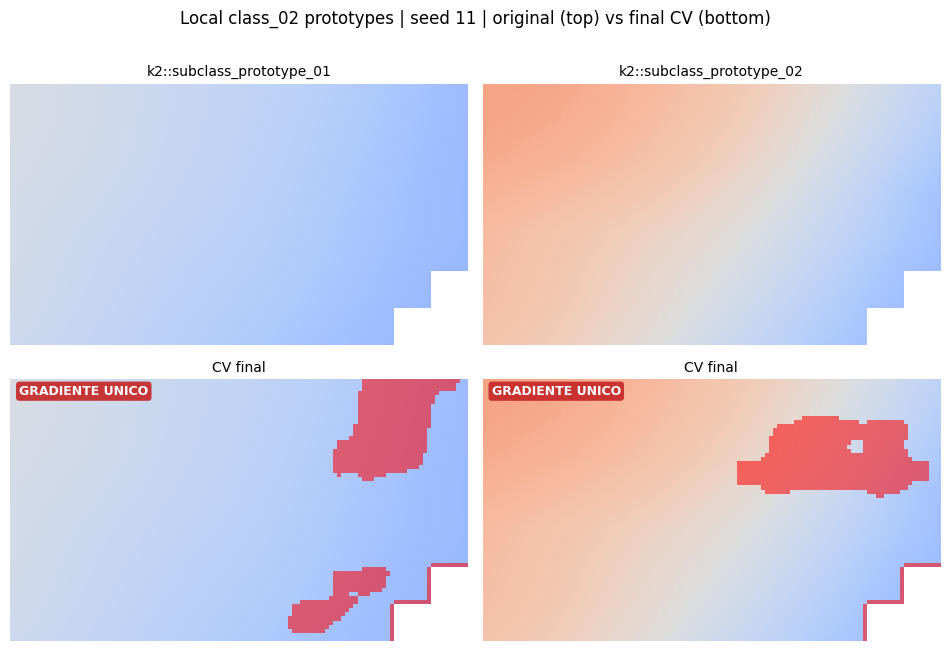

In [12]:
REGIME_LABEL_TEXT = {
    'homogeneous': 'HOMOGENEO',
    'single_gradient': 'GRADIENTE UNICO',
    'multi_regime': 'MULTI-REGIME',
}

REGIME_LABEL_COLOR = {
    'homogeneous': '#2E7D32',
    'single_gradient': '#C62828',
    'multi_regime': '#1565C0',
}


def show_original(ax, arr, mask, title):
    arr_plot = arr.astype(np.float32, copy=True)
    arr_plot[~mask] = np.nan
    ax.imshow(
        arr_plot,
        origin='lower',
        cmap=EXPECTED_CMAP,
        vmin=EXPECTED_VMIN,
        vmax=EXPECTED_VMAX,
        aspect='auto',
    )
    ax.set_title(title, fontsize=10)
    ax.axis('off')


def _add_badge(ax, regime_label):
    text = REGIME_LABEL_TEXT.get(regime_label, regime_label)
    color = REGIME_LABEL_COLOR.get(regime_label, '#555555')
    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        color='white',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor=color, edgecolor='none', alpha=0.92),
    )


def show_final_cv(ax, arr, mask, aux, regime_label, title):
    arr_plot = arr.astype(np.float32, copy=True)
    arr_plot[~mask] = np.nan
    ax.imshow(
        arr_plot,
        origin='lower',
        cmap=EXPECTED_CMAP,
        vmin=EXPECTED_VMIN,
        vmax=EXPECTED_VMAX,
        aspect='auto',
    )

    if regime_label == 'single_gradient':
        front = aux.get('front_binary')
        if front is not None and np.any(front):
            front_overlay = np.zeros((arr.shape[0], arr.shape[1], 4), dtype=np.float32)
            front_overlay[..., 0] = 1.0
            front_overlay[..., 3] = front.astype(np.float32) * 0.55
            ax.imshow(front_overlay, origin='lower', aspect='auto')

    elif regime_label == 'multi_regime':
        low = aux.get('region_low')
        high = aux.get('region_high')
        if low is not None and high is not None:
            region_map = np.full(arr.shape, np.nan, dtype=np.float32)
            region_map[low] = 0.0
            region_map[high] = 1.0
            ax.imshow(
                region_map,
                origin='lower',
                cmap=ListedColormap(['#3A86FF', '#FF8C42']),
                vmin=0,
                vmax=1,
                alpha=0.45,
                aspect='auto',
            )

    _add_badge(ax, regime_label)
    ax.set_title(title, fontsize=10)
    ax.axis('off')


def plot_simple_cv_grid(df, data_dict, aux_dict, key_col, figure_title):
    if df.empty:
        print(f'No rows available for: {figure_title}')
        return

    keys = list(df[key_col])
    n = len(keys)
    cols = min(4, max(1, n))
    row_blocks = math.ceil(n / cols)
    total_rows = row_blocks * 2

    fig, axes = plt.subplots(total_rows, cols, figsize=(4.8 * cols, 3.2 * total_rows), squeeze=False)
    row_lookup = {row[key_col]: row for _, row in df.iterrows()}

    for i, key in enumerate(keys):
        block = i // cols
        col = i % cols
        r_top = block * 2
        r_bottom = r_top + 1

        item = data_dict[key]
        row = row_lookup[key]
        label = row['regime_label']

        show_original(axes[r_top][col], item['arr'], item['mask'], title=str(key))
        show_final_cv(axes[r_bottom][col], item['arr'], item['mask'], aux_dict[key], label, title='CV final')

    for j in range(n, row_blocks * cols):
        block = j // cols
        col = j % cols
        r_top = block * 2
        r_bottom = r_top + 1
        axes[r_top][col].axis('off')
        axes[r_bottom][col].axis('off')

    fig.suptitle(figure_title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_simple_cv_grid(
    df=simple_global_df.sort_values('prototype_name').reset_index(drop=True),
    data_dict=global_data,
    aux_dict=simple_global_aux,
    key_col='prototype_name',
    figure_title=f'Global prototypes | seed {SEED_ID} | original (top) vs final CV (bottom)',
)

plot_simple_cv_grid(
    df=simple_local_df.sort_values(['k', 'prototype_name']).reset_index(drop=True),
    data_dict=local_data,
    aux_dict=simple_local_aux,
    key_col='key',
    figure_title=f'Local class_02 prototypes | seed {SEED_ID} | original (top) vs final CV (bottom)',
)


## Image-only regime analysis

Alternative pipeline based only on `*_clean.png` (RGBA), using alpha as valid mask and simple color score (`R - B`) for regime classification.


In [13]:
# ------------------------------------------------------------
# Image-only thresholds (conservative defaults)
# ------------------------------------------------------------
IMAGE_ONLY_RULES = {
    # Strong homogeneous evidence (very low spread / weak separation)
    'homogeneous_std_low_max': 12.0,
    'homogeneous_min_region_tiny_max': 0.12,
    'homogeneous_inter_diff_low_max': 18.0,

    # Moderate-spread homogeneous profile (single dominant body + mild edge)
    'homogeneous_std_mid_max': 28.0,
    'homogeneous_min_region_mid_max': 0.34,
    'homogeneous_inter_diff_mid_min': 35.0,
    'homogeneous_inter_diff_mid_max': 60.0,
    'homogeneous_p90_grad_mid_max': 0.66,

    # Multi-regime only with strong evidence
    'multi_min_region_ratio_min': 0.18,
    'multi_inter_region_diff_min': 60.0,
    'multi_coherence_min': 0.65,
    'multi_p90_grad_min': 0.68,
}

IMAGE_ONLY_GRAD_SIGMA = 1.0


if not HAS_CV2:
    raise RuntimeError('OpenCV is required for image-only analysis. Install opencv-python-headless in Colab.')


def load_clean_png_rgba(png_path):
    png_path = Path(png_path)
    img = cv2.imread(str(png_path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f'Could not read PNG: {png_path}')

    if img.ndim == 2:
        rgb = np.stack([img, img, img], axis=-1)
        alpha = np.full(img.shape, 255, dtype=np.uint8)
    elif img.ndim == 3 and img.shape[2] == 4:
        rgba = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
        rgb = rgba[..., :3]
        alpha = rgba[..., 3]
    elif img.ndim == 3 and img.shape[2] == 3:
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        alpha = np.full(rgb.shape[:2], 255, dtype=np.uint8)
    else:
        raise ValueError(f'Unsupported PNG shape for {png_path}: {img.shape}')

    rgb = rgb.astype(np.float32, copy=False)
    alpha = alpha.astype(np.uint8, copy=False)
    mask = alpha > 0
    return rgb, alpha, mask


def color_score_rb(rgb, mask):
    score = rgb[..., 0].astype(np.float32) - rgb[..., 2].astype(np.float32)
    score = score.astype(np.float32, copy=False)
    score[~mask] = np.nan
    return score


def score_global_metrics(score, mask):
    vals = score[mask & np.isfinite(score)]
    if vals.size == 0:
        return {
            'std_temp': float('nan'),
            'iqr_temp': float('nan'),
            'range_temp': float('nan'),
            'score_mean': float('nan'),
        }

    p25, p75 = np.percentile(vals, [25, 75])
    return {
        'std_temp': float(np.nanstd(vals)),
        'iqr_temp': float(p75 - p25),
        'range_temp': float(np.nanmax(vals) - np.nanmin(vals)),
        'score_mean': float(np.nanmean(vals)),
    }


def otsu_on_color_score(score, mask):
    valid = mask & np.isfinite(score)
    vals = score[valid]

    labels = np.full(score.shape, -1, dtype=np.int8)
    region_low = np.zeros(score.shape, dtype=bool)
    region_high = np.zeros(score.shape, dtype=bool)

    if vals.size == 0:
        return {
            'threshold': float('nan'),
            'threshold_method': 'empty',
            'labels': labels,
            'region_low': region_low,
            'region_high': region_high,
        }

    threshold = float(np.nanmean(vals))
    threshold_method = 'mean_fallback'

    if HAS_SKIMAGE and threshold_otsu is not None and np.unique(vals).size > 1:
        try:
            threshold = float(threshold_otsu(vals))
            threshold_method = 'otsu'
        except Exception:
            threshold_method = 'mean_fallback'

    region_low = valid & (score < threshold)
    region_high = valid & (~region_low)
    labels[region_low] = 0
    labels[region_high] = 1

    return {
        'threshold': threshold,
        'threshold_method': threshold_method,
        'labels': labels,
        'region_low': region_low,
        'region_high': region_high,
    }


def largest_component_ratio(binary_region):
    region = np.asarray(binary_region, dtype=bool)
    total = int(region.sum())
    if total == 0:
        return 0.0

    comp_map, n_comp = ndi.label(region)
    if n_comp == 0:
        return 0.0

    comp_sizes = np.bincount(comp_map.ravel())[1:]
    if comp_sizes.size == 0:
        return 0.0

    largest = int(comp_sizes.max())
    return float(largest / total)


def region_metrics_from_score(score, mask, region_low, region_high):
    valid = mask & np.isfinite(score)
    n_valid = int(valid.sum())
    if n_valid == 0:
        return {
            'low_ratio': float('nan'),
            'high_ratio': float('nan'),
            'min_region_ratio': float('nan'),
            'inter_region_diff': float('nan'),
            'coherence_low': float('nan'),
            'coherence_high': float('nan'),
            'coherence_min': float('nan'),
        }

    n_low = int(region_low.sum())
    n_high = int(region_high.sum())

    low_ratio = float(n_low / n_valid)
    high_ratio = float(n_high / n_valid)
    min_region_ratio = float(min(low_ratio, high_ratio))

    mean_low = float(np.nanmean(score[region_low])) if n_low > 0 else float('nan')
    mean_high = float(np.nanmean(score[region_high])) if n_high > 0 else float('nan')
    if np.isfinite(mean_low) and np.isfinite(mean_high):
        inter_region_diff = float(abs(mean_high - mean_low))
    else:
        inter_region_diff = 0.0

    coherence_low = float(largest_component_ratio(region_low))
    coherence_high = float(largest_component_ratio(region_high))
    coherence_min = float(min(coherence_low, coherence_high))

    return {
        'low_ratio': low_ratio,
        'high_ratio': high_ratio,
        'min_region_ratio': min_region_ratio,
        'inter_region_diff': inter_region_diff,
        'coherence_low': coherence_low,
        'coherence_high': coherence_high,
        'coherence_min': coherence_min,
    }


def image_front_metrics(score, mask, grad_sigma=IMAGE_ONLY_GRAD_SIGMA):
    valid = mask & np.isfinite(score)
    grad_mag = np.full(score.shape, np.nan, dtype=np.float32)
    front_binary = np.zeros(score.shape, dtype=bool)

    if not np.any(valid):
        return {
            'mean_grad': float('nan'),
            'p90_grad': float('nan'),
            'front_area_ratio': float('nan'),
            'grad_mag': grad_mag,
            'front_binary': front_binary,
        }

    # Light weighted smoothing to stabilize gradients without leaking outside alpha-mask.
    score_for_grad = np.asarray(score, dtype=np.float32)
    if grad_sigma is not None and grad_sigma > 0:
        w = valid.astype(np.float32)
        s0 = np.where(valid, score_for_grad, 0.0).astype(np.float32, copy=False)
        num = ndi.gaussian_filter(s0 * w, sigma=float(grad_sigma), mode='nearest')
        den = ndi.gaussian_filter(w, sigma=float(grad_sigma), mode='nearest')
        ok = den > 1e-6
        smoothed = np.full(score.shape, np.nan, dtype=np.float32)
        smoothed[ok] = (num[ok] / den[ok]).astype(np.float32, copy=False)
        score_for_grad = smoothed

    fill_value = float(np.nanmean(score_for_grad[valid]))
    score_pad = np.where(valid, score_for_grad, fill_value).astype(np.float32, copy=False)
    gy, gx = np.gradient(score_pad)
    grad = np.hypot(gx, gy).astype(np.float32, copy=False)
    grad[~valid] = np.nan
    grad_mag = grad

    gvals = grad_mag[valid]
    mean_grad = float(np.nanmean(gvals))

    positive = gvals[gvals > 0]
    if positive.size == 0:
        p90_grad = 0.0
        front_area_ratio = 0.0
    else:
        p90_grad = float(np.percentile(positive, 90))
        front_binary = valid & (grad_mag >= p90_grad)
        front_area_ratio = float(front_binary.sum() / valid.sum())

    return {
        'mean_grad': mean_grad,
        'p90_grad': p90_grad,
        'front_area_ratio': front_area_ratio,
        'grad_mag': grad_mag,
        'front_binary': front_binary,
    }


def extract_image_only_metrics(prototype_name, clean_png_path):
    rgb, alpha, mask = load_clean_png_rgba(clean_png_path)
    score = color_score_rb(rgb, mask)

    gm = score_global_metrics(score, mask)
    seg = otsu_on_color_score(score, mask)
    rm = region_metrics_from_score(score, mask, seg['region_low'], seg['region_high'])
    fm = image_front_metrics(score, mask, grad_sigma=IMAGE_ONLY_GRAD_SIGMA)

    row = {
        'prototype_name': prototype_name,
        'clean_png_path': str(clean_png_path),
        'grad_sigma': float(IMAGE_ONLY_GRAD_SIGMA),
        'threshold': float(seg['threshold']) if np.isfinite(seg['threshold']) else float('nan'),
        'threshold_method': seg['threshold_method'],
        'std_temp': gm['std_temp'],
        'iqr_temp': gm['iqr_temp'],
        'range_temp': gm['range_temp'],
        'score_mean': gm['score_mean'],
        'low_ratio': rm['low_ratio'],
        'high_ratio': rm['high_ratio'],
        'min_region_ratio': rm['min_region_ratio'],
        'inter_region_diff': rm['inter_region_diff'],
        'coherence_low': rm['coherence_low'],
        'coherence_high': rm['coherence_high'],
        'coherence_min': rm['coherence_min'],
        'mean_grad': fm['mean_grad'],
        'p90_grad': fm['p90_grad'],
        'front_area_ratio': fm['front_area_ratio'],
    }

    aux = {
        'rgb': rgb,
        'alpha': alpha,
        'mask': mask,
        'score': score,
        'labels': seg['labels'],
        'region_low': seg['region_low'],
        'region_high': seg['region_high'],
        'grad_mag': fm['grad_mag'],
        'front_binary': fm['front_binary'],
    }
    return row, aux


def decide_regime_label_image_only(row, rules=IMAGE_ONLY_RULES):
    std_temp = float(row.get('std_temp', np.nan))
    min_region_ratio = float(row.get('min_region_ratio', np.nan))
    inter_region_diff = float(row.get('inter_region_diff', np.nan))
    coherence_min = float(row.get('coherence_min', np.nan))
    p90_grad = float(row.get('p90_grad', np.nan))

    homogeneous_low_spread = (
        std_temp < rules['homogeneous_std_low_max']
        and (
            min_region_ratio < rules['homogeneous_min_region_tiny_max']
            or inter_region_diff < rules['homogeneous_inter_diff_low_max']
        )
    )

    homogeneous_mid_profile = (
        std_temp < rules['homogeneous_std_mid_max']
        and min_region_ratio < rules['homogeneous_min_region_mid_max']
        and rules['homogeneous_inter_diff_mid_min'] <= inter_region_diff <= rules['homogeneous_inter_diff_mid_max']
        and p90_grad <= rules['homogeneous_p90_grad_mid_max']
    )

    if homogeneous_low_spread or homogeneous_mid_profile:
        return 'homogeneous'

    multi_regime = (
        min_region_ratio >= rules['multi_min_region_ratio_min']
        and inter_region_diff >= rules['multi_inter_region_diff_min']
        and coherence_min >= rules['multi_coherence_min']
        and p90_grad >= rules['multi_p90_grad_min']
    )
    if multi_regime:
        return 'multi_regime'

    return 'single_gradient'


In [14]:
# ----------------------
# Apply image-only to global prototypes
# ----------------------
image_global_rows = []
image_global_aux = {}

for rec in sorted(global_records, key=lambda r: r['name']):
    row, aux = extract_image_only_metrics(rec['name'], rec['clean_png_path'])
    row['seed'] = SEED_ID
    row['scope'] = 'global'
    row['regime_label'] = decide_regime_label_image_only(row)
    image_global_rows.append(row)

    aux['regime_label'] = row['regime_label']
    aux['prototype_name'] = rec['name']
    image_global_aux[rec['name']] = aux

image_global_df = pd.DataFrame(image_global_rows).sort_values('prototype_name').reset_index(drop=True)

print('Image-only global regime labels:')
display(image_global_df[['prototype_name', 'regime_label', 'std_temp', 'min_region_ratio', 'inter_region_diff', 'coherence_min']])
display(image_global_df['regime_label'].value_counts(dropna=False))


# ----------------------
# Apply image-only to local class_02 prototypes
# ----------------------
image_local_rows = []
image_local_aux = {}

for rec in sorted(local_records, key=lambda r: (r['k'], r['name'])):
    key = f"{rec['k']}::{rec['name']}"
    row, aux = extract_image_only_metrics(rec['name'], rec['clean_png_path'])
    row['seed'] = SEED_ID
    row['scope'] = 'local_class02'
    row['k'] = rec['k']
    row['key'] = key
    row['regime_label'] = decide_regime_label_image_only(row)
    image_local_rows.append(row)

    aux['regime_label'] = row['regime_label']
    aux['prototype_name'] = rec['name']
    image_local_aux[key] = aux

image_local_df = pd.DataFrame(image_local_rows).sort_values(['k', 'prototype_name']).reset_index(drop=True)

print('Image-only local class_02 regime labels:')
display(image_local_df[['k', 'prototype_name', 'key', 'regime_label', 'std_temp', 'min_region_ratio', 'inter_region_diff', 'coherence_min']])
display(image_local_df['regime_label'].value_counts(dropna=False))


Image-only global regime labels:


,prototype_name,regime_label,std_temp,min_region_ratio,inter_region_diff,coherence_min
0,prototype_class_01,homogeneous,4.398037,0.405620,7.637772,1.0
1,prototype_class_02,single_gradient,28.987122,0.461493,50.028660,1.0
2,prototype_class_03,multi_regime,73.421005,0.387826,135.209414,1.0
3,prototype_class_04,homogeneous,26.251936,0.302222,48.598579,1.0
4,prototype_class_05,single_gradient,10.266083,0.207880,22.546883,1.0


regime_label
homogeneous        2
single_gradient    2
multi_regime       1
Name: count, dtype: int64

Image-only local class_02 regime labels:


,k,prototype_name,key,regime_label,std_temp,min_region_ratio,inter_region_diff,coherence_min
0,k2,subclass_prototype_01,k2::subclass_prototype_01,single_gradient,23.952049,0.472028,41.206181,1.0
1,k2,subclass_prototype_02,k2::subclass_prototype_02,multi_regime,59.475231,0.427683,106.116890,1.0


regime_label
single_gradient    1
multi_regime       1
Name: count, dtype: int64

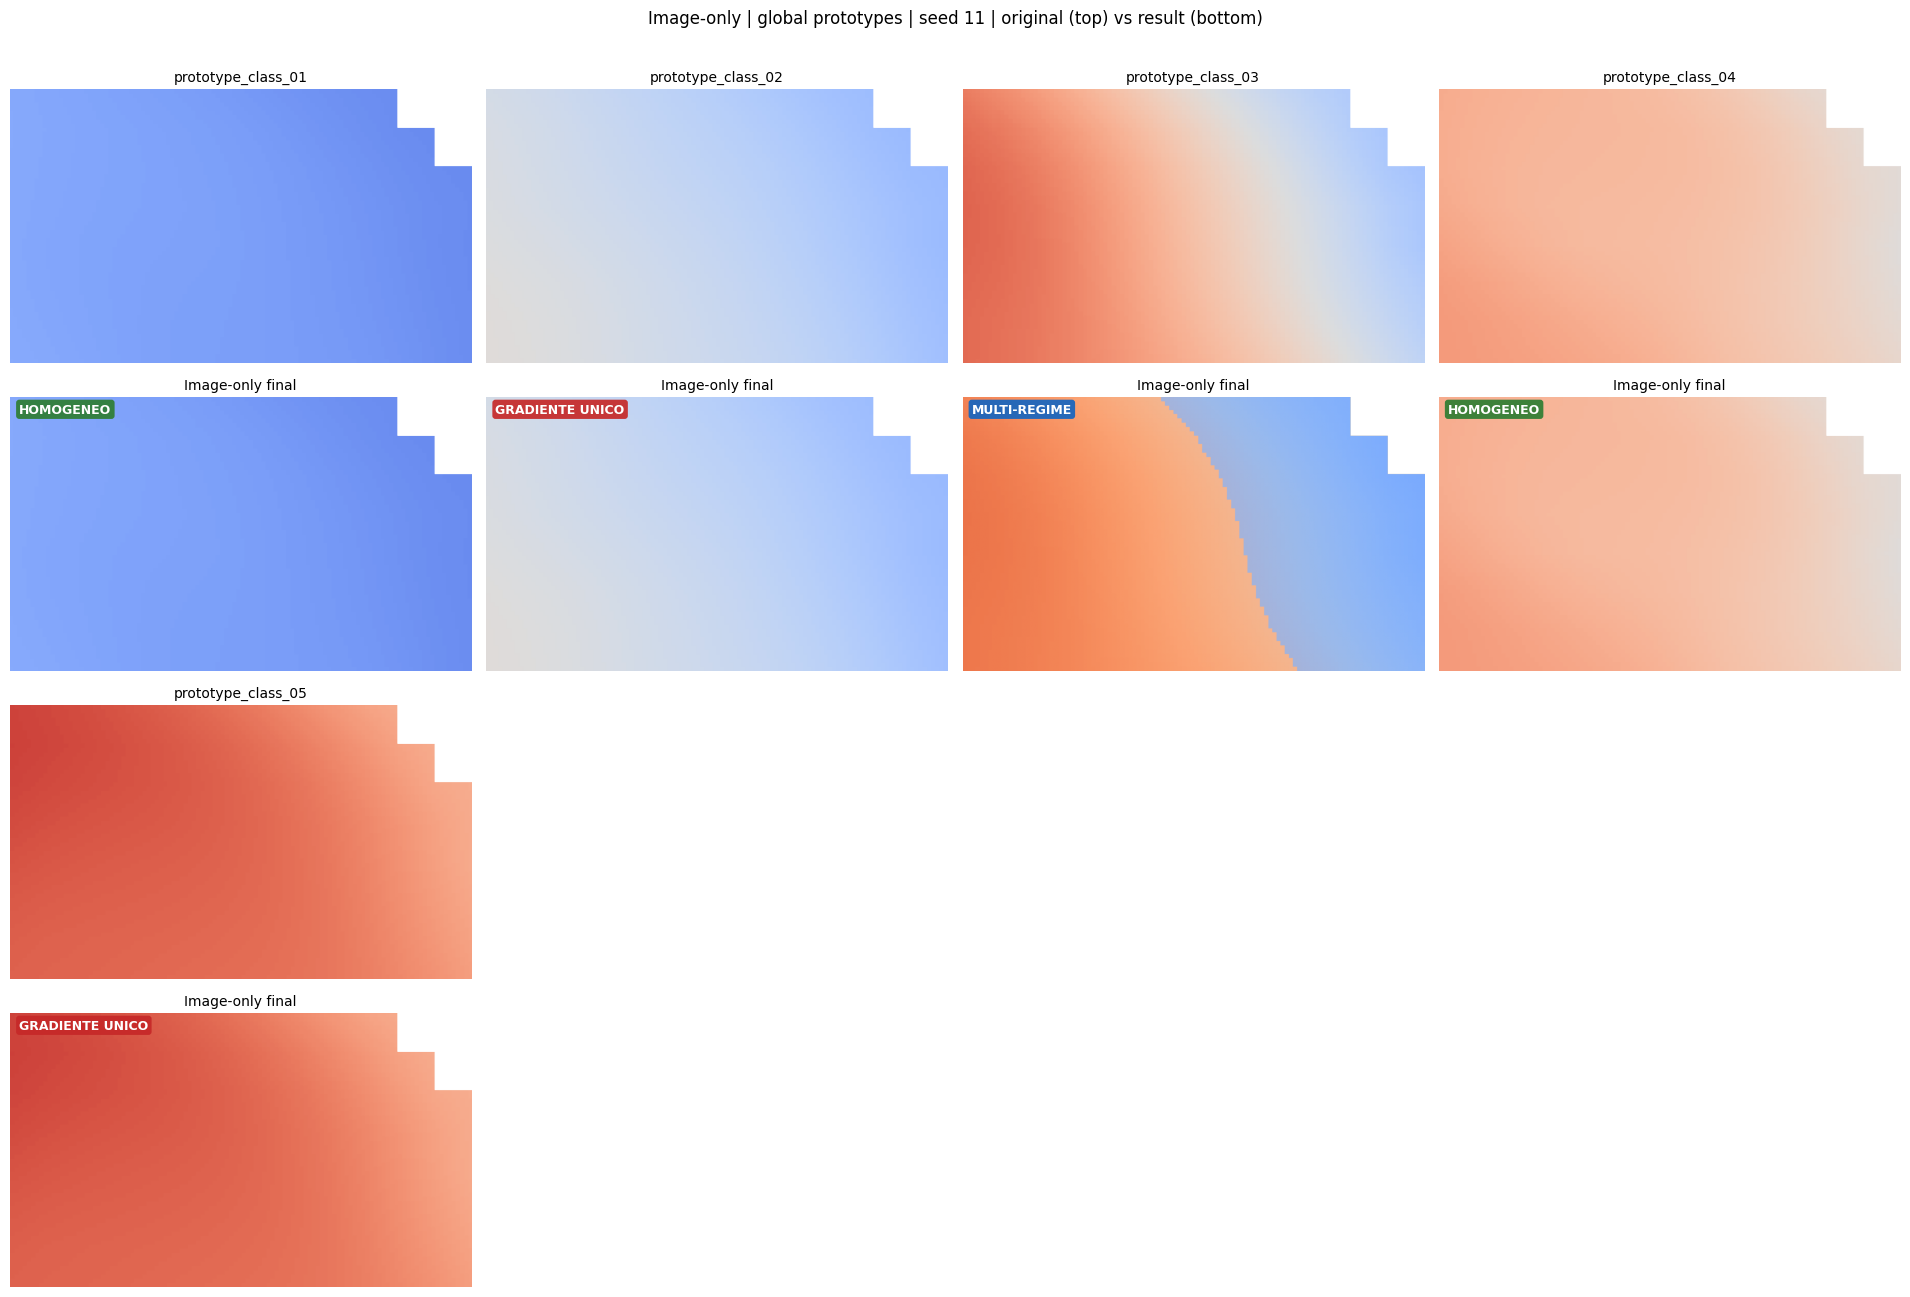

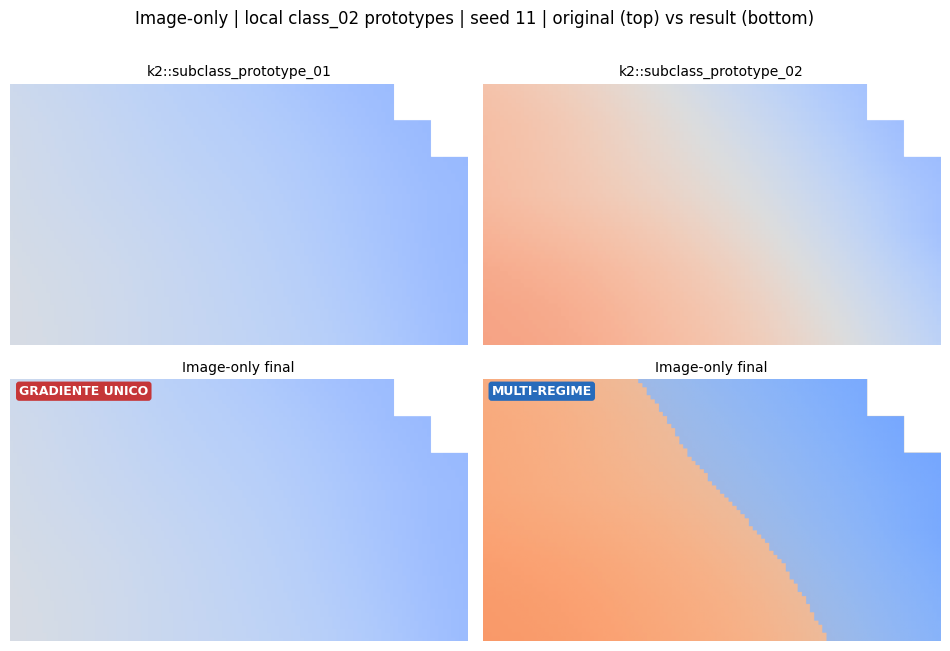

In [15]:
IMAGE_ONLY_LABEL_TEXT = {
    'homogeneous': 'HOMOGENEO',
    'single_gradient': 'GRADIENTE UNICO',
    'multi_regime': 'MULTI-REGIME',
}

IMAGE_ONLY_LABEL_COLOR = {
    'homogeneous': '#2E7D32',
    'single_gradient': '#C62828',
    'multi_regime': '#1565C0',
}


def _rgba_display(rgb, mask):
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    rgba[..., :3] = np.clip(rgb / 255.0, 0.0, 1.0)
    rgba[..., 3] = mask.astype(np.float32)
    return rgba


def _add_image_only_badge(ax, regime_label):
    text = IMAGE_ONLY_LABEL_TEXT.get(regime_label, regime_label)
    color = IMAGE_ONLY_LABEL_COLOR.get(regime_label, '#555555')
    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        color='white',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor=color, edgecolor='none', alpha=0.92),
    )


def show_image_only_original(ax, res, title):
    ax.imshow(_rgba_display(res['rgb'], res['mask']), origin='lower', aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.axis('off')


def show_image_only_result(ax, res, title):
    rgb = res['rgb']
    mask = res['mask']
    regime_label = res['regime_label']

    ax.imshow(_rgba_display(rgb, mask), origin='lower', aspect='auto')

    # Overlay only for multi_regime to keep visualization clean.
    if regime_label == 'multi_regime':
        region_map = np.full(mask.shape, np.nan, dtype=np.float32)
        region_map[res['region_low']] = 0.0
        region_map[res['region_high']] = 1.0
        ax.imshow(
            region_map,
            origin='lower',
            cmap=ListedColormap(['#3A86FF', '#FF8C42']),
            vmin=0,
            vmax=1,
            alpha=0.40,
            aspect='auto',
        )

    _add_image_only_badge(ax, regime_label)
    ax.set_title(title, fontsize=10)
    ax.axis('off')


def plot_image_only_grid(df, aux_dict, key_col, figure_title):
    if df.empty:
        print(f'No rows available for: {figure_title}')
        return

    keys = list(df[key_col])
    n = len(keys)
    cols = min(4, max(1, n))
    row_blocks = math.ceil(n / cols)
    total_rows = row_blocks * 2

    fig, axes = plt.subplots(total_rows, cols, figsize=(4.8 * cols, 3.2 * total_rows), squeeze=False)

    for i, key in enumerate(keys):
        block = i // cols
        col = i % cols
        r_top = block * 2
        r_bottom = r_top + 1

        res = aux_dict[key]
        show_image_only_original(axes[r_top][col], res, title=str(key))
        show_image_only_result(axes[r_bottom][col], res, title='Image-only final')

    for j in range(n, row_blocks * cols):
        block = j // cols
        col = j % cols
        r_top = block * 2
        r_bottom = r_top + 1
        axes[r_top][col].axis('off')
        axes[r_bottom][col].axis('off')

    fig.suptitle(figure_title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_image_only_grid(
    df=image_global_df.sort_values('prototype_name').reset_index(drop=True),
    aux_dict=image_global_aux,
    key_col='prototype_name',
    figure_title=f'Image-only | global prototypes | seed {SEED_ID} | original (top) vs result (bottom)',
)

plot_image_only_grid(
    df=image_local_df.sort_values(['k', 'prototype_name']).reset_index(drop=True),
    aux_dict=image_local_aux,
    key_col='key',
    figure_title=f'Image-only | local class_02 prototypes | seed {SEED_ID} | original (top) vs result (bottom)',
)


## Optional HSL exploration on clean PNGs

Exploratory only. This section does **not** affect the `arr` + `mask` pipeline, the image-only pipeline, or any final CSV export.


In [16]:
RUN_OPTIONAL_HSL_EXPLORATION = False


def optional_hsl_exploration(records, max_items=4):
    print('Exploratory only: this does not feed simple or image-only classifiers.')

    if not HAS_CV2:
        print('OpenCV not available. Skipping optional HSL exploration.')
        return

    selected = [r for r in records if Path(r['clean_png_path']).exists()][:max_items]
    if len(selected) == 0:
        print('No *_clean.png files found for optional exploration.')
        return

    fig, axes = plt.subplots(len(selected), 3, figsize=(12, 3.5 * len(selected)), squeeze=False)

    for i, rec in enumerate(selected):
        img_bgr = cv2.imread(str(rec['clean_png_path']))
        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)
        h_ch = img_hls[:, :, 0]
        l_ch = img_hls[:, :, 1]

        axes[i][0].imshow(img_rgb)
        axes[i][0].set_title(f"{rec['name']} | clean PNG")
        axes[i][0].axis('off')

        axes[i][1].imshow(h_ch, cmap='hsv')
        axes[i][1].set_title('H channel (exploratory)')
        axes[i][1].axis('off')

        axes[i][2].imshow(l_ch, cmap='gray')
        axes[i][2].set_title('L channel (exploratory)')
        axes[i][2].axis('off')

    fig.suptitle('Optional HSL exploration on clean PNGs (not used in classification)', y=1.01)
    fig.tight_layout()
    plt.show()


if RUN_OPTIONAL_HSL_EXPLORATION:
    optional_hsl_exploration(global_records, max_items=4)
else:
    print('Set RUN_OPTIONAL_HSL_EXPLORATION = True to run this optional section.')


Set RUN_OPTIONAL_HSL_EXPLORATION = True to run this optional section.


## Export CSV results

In [17]:
global_csv = NOTEBOOK_OUTPUT_DIR / f'cv_features_global_seed{SEED_ID}.csv'
local_csv = NOTEBOOK_OUTPUT_DIR / f'cv_features_local_class02_seed{SEED_ID}.csv'
validation_csv = NOTEBOOK_OUTPUT_DIR / f'cv_validation_seed{SEED_ID}.csv'

simple_global_csv = NOTEBOOK_OUTPUT_DIR / f'cv_features_global_seed{SEED_ID}_simple.csv'
simple_local_csv = NOTEBOOK_OUTPUT_DIR / f'cv_features_local_class02_seed{SEED_ID}_simple.csv'

image_global_csv = NOTEBOOK_OUTPUT_DIR / f'cv_features_global_seed{SEED_ID}_image_only.csv'
image_local_csv = NOTEBOOK_OUTPUT_DIR / f'cv_features_local_class02_seed{SEED_ID}_image_only.csv'

features_global_df.to_csv(global_csv, index=False)
features_local_df.to_csv(local_csv, index=False)
validation_df.to_csv(validation_csv, index=False)

simple_global_df.to_csv(simple_global_csv, index=False)
simple_local_df.to_csv(simple_local_csv, index=False)

image_global_df.to_csv(image_global_csv, index=False)
image_local_df.to_csv(image_local_csv, index=False)

print('CSV global guardado em            :', global_csv)
print('CSV local guardado em             :', local_csv)
print('CSV validacao guardado em         :', validation_csv)
print('CSV simple global guardado em     :', simple_global_csv)
print('CSV simple local guardado em      :', simple_local_csv)
print('CSV image-only global guardado em :', image_global_csv)
print('CSV image-only local guardado em  :', image_local_csv)


CSV global guardado em            : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\cv_notebook_outputs_seed11\cv_features_global_seed11.csv
CSV local guardado em             : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\cv_notebook_outputs_seed11\cv_features_local_class02_seed11.csv
CSV validacao guardado em         : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\cv_notebook_outputs_seed11\cv_validation_seed11.csv
CSV simple global guardado em     : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328\computer_vision_exports_seed11\cv_notebook_outputs_seed11\cv_features_global_seed11_simple.csv
CSV simple local guardado em      : C:\Users\pedro\Documents\Filipa_dados\results\final_working_pipeline\final_working_20260328